<a href="https://colab.research.google.com/github/Noshir0/lab4/blob/main/hw_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div align="center">

<center>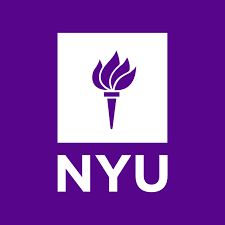</center>

<h1 style="color:#57068C;font-family:Helvetica,Arial,sans-serif;margin-bottom:0">DS4EVERYONE — DS-UA 9111</h1>
<h3 style="color:#000;font-family:Helvetica,Arial,sans-serif;margin-top:4px">New York University</h3>

<hr style="border:0;border-top:2px solid #57068C;width:60%">

<h2 style="font-family:Helvetica,Arial,sans-serif;color:#222;margin-bottom:0">Session 10 — Decision Trees</h2>
<h3 style="font-family:Helvetica,Arial,sans-serif;color:#444;margin-top:6px;font-weight:400">Lab · Explainable Decision Trees + W&B Tuning — Student Version</h3>

<p style="font-family:Helvetica,Arial,sans-serif;font-size:14px;color:#555;margin-top:14px">
Instructor: <b>Professor Gaëtan Brison ©</b><br>Bachelor — Final Year · Spring Semester
</p>

<span style="display:inline-block;padding:6px 14px;border-radius:14px;background:#A05CC9;color:#fff;font-family:Helvetica,Arial,sans-serif;font-size:12px;letter-spacing:1px">EXERCISES · STUDENT VERSION</span>

</div>

---


## 🧭 How to use this notebook

Each exercise contains a short prompt, a code cell with **`# TODO:`** placeholders for you to fill in, and a follow-up explanation.  
**Do not** look at the solutions notebook until you have made a serious attempt yourself — productive struggle is how you build coding intuition.  

If a cell raises an exception, that is *information*, not failure. Read the message, hypothesize, fix, repeat.

**This lab needs two free accounts/tools beyond the usual stack:**

1. **Graphviz** — the Python package *and* the system binary (`brew install graphviz` / `sudo apt-get install graphviz`). Colab has it pre-installed.

2. **Weights & Biases** — a free account at [wandb.ai](https://wandb.ai); copy your API key from [wandb.ai/authorize](https://wandb.ai/authorize) for the `wandb.login()` step.

Work top-to-bottom: fill each **`# TODO`** / `...`, run the cell, then read the *After* note to check your understanding. The matching **Solutions** notebook has every answer — use it only after a genuine attempt.

---


## 📖 Table of Contents

- **Part 1** — [Setup & the Breast Cancer Dataset](#part-1)
- **Part 2** — [Your First Decision Tree](#part-2)
- **Part 3** — [Explaining the Tree with Graphviz](#part-3)
- **Part 4** — [Gini Impurity vs Entropy](#part-4)
- **Part 5** — [Feature Importance](#part-5)
- **Part 6** — [Underfitting vs Overfitting — the Depth Curve](#part-6)
- **Part 7** — [Hyperparameter Tuning with Weights & Biases](#part-7)
- **Part 8** — [Final Held-out Evaluation](#part-8)
- **Bonus** — [Bonus Questions](#bonus)

---


<a id='part-1'></a>

## Part 1 — Setup & the Breast Cancer Dataset

A decision tree answers a question by walking an example from the **root** down a chain of yes/no **conditions** until it reaches a **leaf** that holds the prediction (see the lecture slides). We will build, *explain*, and *tune* one on the **Breast Cancer Wisconsin** dataset — the same data behind the `radius_mean` / `concave points_mean` scatter and tree in the slides. It ships with scikit-learn, so there is no CSV to download.



**📝 Before you run this cell**

We import the scientific stack plus the three tools this lab is built around: scikit-learn (`DecisionTreeClassifier` + the tree exporters), **Graphviz** (to draw the tree), and later **Weights & Biases**. Uncomment the install line the first time you run this in a fresh environment.

> **Heads-up on Graphviz.** The `graphviz` Python package is only a thin wrapper. To render images you also need the *system* Graphviz binary: `brew install graphviz` (macOS) or `sudo apt-get install graphviz` (Ubuntu). Google Colab already has it.

In [1]:
# Run once if needed (Colab already ships most of these):
# !pip install scikit-learn graphviz optuna wandb plotly --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tools we will need throughout the lab
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text, plot_tree
from sklearn import metrics
import graphviz

NYU_PURPLE = "#57068C"

**🔎 After running the cell**

If the import of `graphviz` fails, install the *system* binary (see the note above) and restart the kernel. Everything else is pure Python and pip-installable.

**📝 Before you run this cell**

We load the dataset **as a DataFrame** (`as_frame=True`) so feature names survive — they are what makes the tree readable later. There are 569 patients, 30 numerical features, and a binary target: **0 = malignant, 1 = benign**.

In [2]:
# Load the Breast Cancer Wisconsin dataset as a DataFrame (as_frame=True)
data = load_breast_cancer(as_frame=True)
X = data.data                       # the 30 features
y = data.target                     # the 0/1 target (0 = malignant, 1 = benign)
class_names = list(data.target_names)   # ['malignant', 'benign']

print(f"Shape          : {X.shape}")
print(f"Target classes : {class_names}")
X.head()

Shape          : (569, 30)
Target classes : [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**🔎 After running the cell**

We have **357 benign vs. 212 malignant** — mildly imbalanced. That is why we will use `StratifiedKFold` later: it preserves this ratio inside every cross-validation fold so no fold accidentally sees almost no malignant cases.

**📝 Before you run this cell**

Before any modelling, reproduce the **“Breast Cancer dataset in 2D”** scatter from the slides: `mean radius` on x, `mean concave points` on y, coloured by diagnosis. This is the intuition for *why* a tree of axis-aligned splits can separate the two classes.

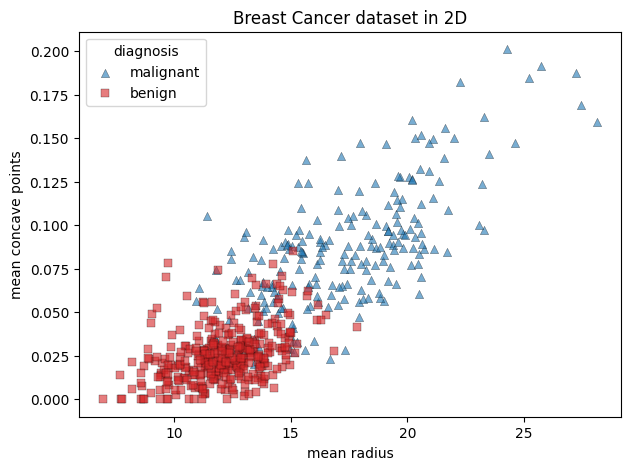

In [3]:
# Scatter 'mean radius' (x) vs 'mean concave points' (y), one colour per diagnosis
fig, ax = plt.subplots(figsize=(7, 5))
styles = [(0, "malignant", "^", "tab:blue"), (1, "benign", "s", "tab:red")]
for label, name, marker, color in styles:
    mask = y == label
    ax.scatter(X.loc[mask, "mean radius"], X.loc[mask, "mean concave points"],
               marker=marker, c=color, label=name,
               alpha=0.6, edgecolor="k", linewidth=0.3)
ax.legend(title="diagnosis")
ax.set_xlabel("mean radius")
ax.set_ylabel("mean concave points")
ax.set_title("Breast Cancer dataset in 2D")
plt.show()

**🔎 After running the cell**

Malignant tumours (blue triangles) sit toward **larger radius and more concave points**; benign tumours (red squares) cluster near the origin. The classes overlap, so no single straight cut is perfect — but a few axis-aligned splits get us most of the way. That is exactly what a decision tree learns.

<a id='part-2'></a>

## Part 2 — Your First Decision Tree

Time to grow our first tree. We hold out a test set, fit a deliberately **shallow** tree (`max_depth=2`), and measure accuracy — reproducing the ~0.90 result from the slides.



**📝 Before you run this cell**

Split into **80% train / 20% test**, stratified on `y` so both sets keep the 357:212 class ratio. `random_state=1` makes the split reproducible — you and your neighbour get identical rows.

In [4]:
# Stratified 80/20 split with random_state=1
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 455 rows | Test: 114 rows


**🔎 After running the cell**

455 training rows, 114 test rows. The test set is now **locked away** — we only touch it once, at the very end, after tuning is finished.

**📝 Before you run this cell**

Fit a `DecisionTreeClassifier` capped at `max_depth=2`. A shallow tree is the whole point here: it is the most *human-readable* model in machine learning, which is what makes the Graphviz explanation in Part 3 meaningful.

In [5]:
# Instantiate DecisionTreeClassifier(max_depth=2, random_state=1), fit, predict
dt = DecisionTreeClassifier(max_depth=2, random_state=1)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
acc = metrics.accuracy_score(y_test, y_pred)
print(f"Test accuracy (max_depth=2): {acc:.4f}")

Test accuracy (max_depth=2): 0.9298


**🔎 After running the cell**

A two-question tree already classifies ~90% of unseen tumours correctly — the same ballpark as the slides. Two well-chosen splits do most of the work; the rest of this lab is about *understanding* and *improving* this model.

<a id='part-3'></a>

## Part 3 — Explaining the Tree with Graphviz

A decision tree is a **white-box** model: you can read exactly why it made any prediction. We render the fitted tree three complementary ways — **Graphviz** (the prettiest), `plot_tree` (no system binary needed), and `export_text` (diff-friendly rules).



**📝 Before you run this cell**

`export_graphviz` turns the fitted tree into a **DOT** string; `graphviz.Source` renders it inline. `filled=True` colours each node by its majority class and `rounded=True` softens the boxes — this is the chart you put on a slide.

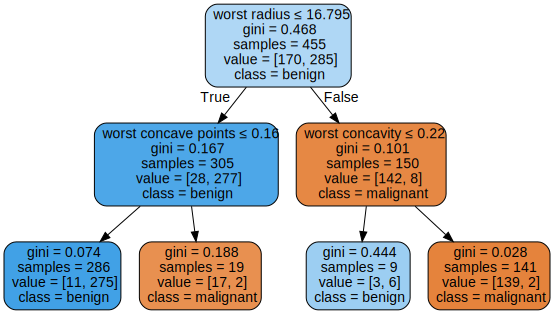

In [6]:
# Build the DOT string with export_graphviz, then render it with graphviz.Source
dot_data = export_graphviz(
    dt, out_file=None,
    feature_names=X.columns, class_names=class_names,
    filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
graph

**🔎 After running the cell**

Read it top-down. The **root** splits on `mean concave points` (or a closely related feature) — the dominant signal we saw in the 2D scatter. Each box shows the split rule, the `gini` impurity, `samples` reaching the node, the class `value` counts, and the predicted `class`. Darker fill = purer node. This *is* the model — no approximation.

**📝 Before you run this cell**

If the system Graphviz binary is unavailable, scikit-learn's own `plot_tree` draws the same tree with matplotlib — zero extra dependencies. Handy on locked-down machines.

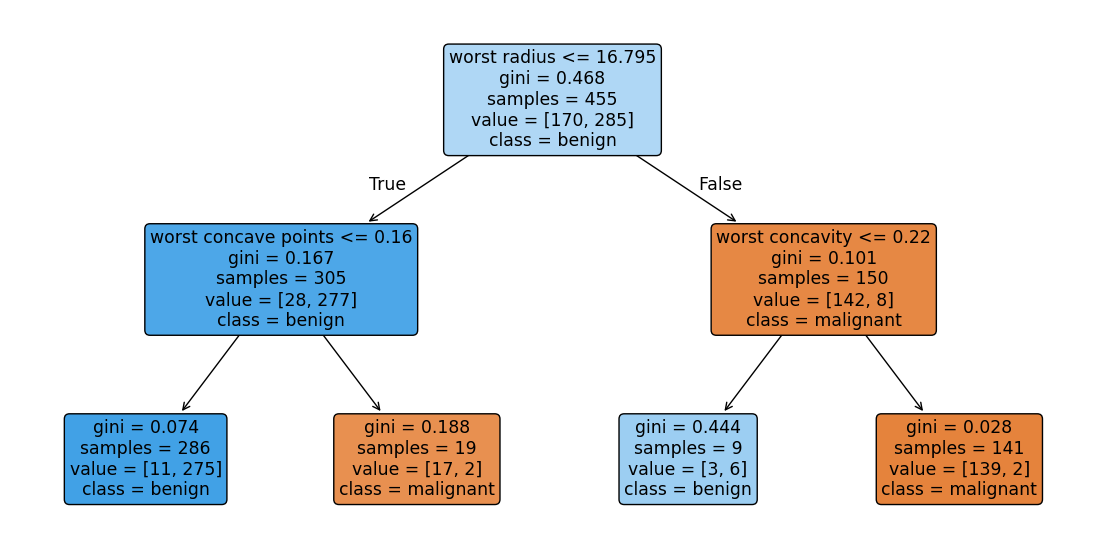

In [7]:
# Draw the same tree with sklearn's plot_tree
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(dt, feature_names=list(X.columns), class_names=class_names,
          filled=True, rounded=True, ax=ax)
plt.show()

**🔎 After running the cell**

Same structure, matplotlib styling. Use Graphviz for polished reports and `plot_tree` for a quick look or when you cannot install the binary.

**📝 Before you run this cell**

`export_text` prints the tree as an indented **rule set** — plain text, so it diffs cleanly in Git and pastes into documentation.

In [8]:
# Print the tree as text rules with export_text
rules = export_text(dt, feature_names=list(X.columns))
print(rules)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.16
|   |   |--- class: 1
|   |--- worst concave points >  0.16
|   |   |--- class: 0
|--- worst radius >  16.80
|   |--- worst concavity <= 0.22
|   |   |--- class: 1
|   |--- worst concavity >  0.22
|   |   |--- class: 0



**🔎 After running the cell**

Each indented block is one branch: *“if concave points ≤ t and radius ≤ s → predict benign”*. Because the rules are exact, a clinician could audit them by hand — the property that makes shallow trees a favourite in regulated, high-stakes settings.

<a id='part-4'></a>

## Part 4 — Gini Impurity vs Entropy

How does the tree *choose* each split? It picks the condition that makes the child nodes as **pure** as possible. Two ways to measure (im)purity: **Gini impurity** and **entropy**.



Picture a jar of multi-coloured marbles and you want each child jar to hold mostly one colour:

- **Gini impurity** is a *messiness score*. One colour only → Gini = 0 (not messy). An even mix → Gini is high. Formally `Gini = 1 - Σ pᵢ²`.
- **Entropy** is a *surprise score*. Pull a marble from a single-colour jar → no surprise → entropy = 0. An even mix → maximum surprise. Formally `Entropy = - Σ pᵢ log₂ pᵢ`.

At every node the tree tries candidate splits and keeps the one that **reduces** impurity the most (the *information gain*). Both metrics are minimised by pure nodes, so they usually pick very similar trees.

**📝 Before you run this cell**

Train the same shallow tree with each criterion and compare test accuracy. On most datasets the difference is tiny — verify that for yourself.

In [9]:
# Loop over ['gini', 'entropy'], fit a depth-2 tree with each, print test accuracy
for criterion in ["gini", "entropy"]:
    clf = DecisionTreeClassifier(max_depth=2, criterion=criterion, random_state=1)
    clf.fit(X_train, y_train)
    acc = metrics.accuracy_score(y_test, clf.predict(X_test))
    print(f"{criterion:>8}: test accuracy = {acc:.4f}")

    gini: test accuracy = 0.9298
 entropy: test accuracy = 0.9298


**🔎 After running the cell**

Gini and entropy land within a hair of each other. Gini is the scikit-learn default because it skips the logarithm and is marginally cheaper to compute; entropy can occasionally produce a slightly more balanced tree. In practice, tune *other* hyperparameters first.

**📝 Before you run this cell**

Let's compute the Gini impurity of the **root** node by hand so the formula is no longer a black box: `Gini = 1 - Σ pᵢ²`, where `pᵢ` is the proportion of class *i*.

In [10]:
# p = class proportions in y_train; gini_root = 1 - sum of p squared
p = y_train.value_counts(normalize=True)
gini_root = 1 - (p ** 2).sum()
print(f"Gini impurity at the root: {gini_root:.4f}")

Gini impurity at the root: 0.4681


**🔎 After running the cell**

The root impurity (~0.47) is close to the 0.5 ceiling because the classes are fairly mixed before any split. Compare this number with the `gini` printed in the **root box** of your Graphviz chart — they match. Every split the tree makes drives this number down.

<a id='part-5'></a>

## Part 5 — Feature Importance

Which of the 30 features does the tree actually rely on? `feature_importances_` answers that — the same diagnostic the slides' Lab 06 asks you to plot.



**📝 Before you run this cell**

`feature_importances_` measures, per feature, the total **reduction in Gini** it contributes across every split where it is used, weighted by how many samples reach that split. We sort and plot the top 10.

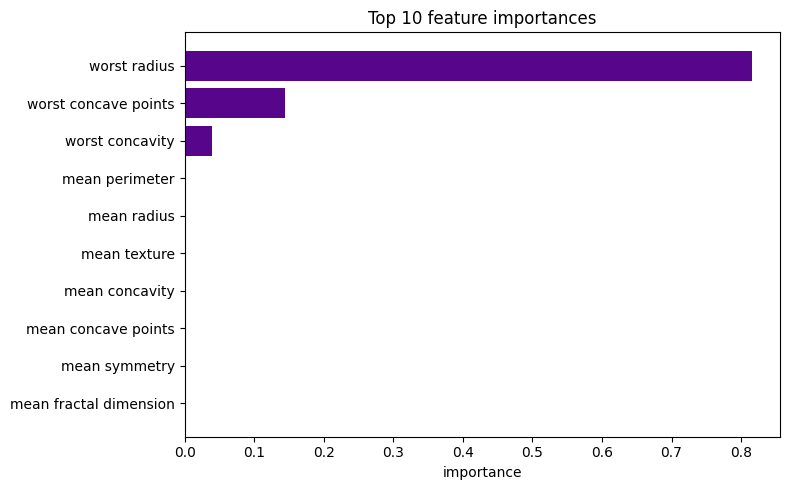

In [11]:
# DataFrame of (feature, importance), sorted, top 10, horizontal bar chart
importances = dt.feature_importances_
fi = (pd.DataFrame({"feature": X.columns, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(10))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color=NYU_PURPLE)
ax.set_xlabel("importance")
ax.set_title("Top 10 feature importances")
plt.tight_layout()
plt.show()

**🔎 After running the cell**

Because the tree is only two levels deep, **just two or three features carry all the importance** (the others are exactly 0 — the tree never split on them). Note the caveat for later in your career: impurity-based importance is **biased toward high-cardinality / continuous features**; permutation importance (Bonus 4) is a fairer, model-agnostic alternative.

<a id='part-6'></a>

## Part 6 — Underfitting vs Overfitting — the Depth Curve

The slides warn: *simple trees underfit, complex trees overfit*. We make that concrete by sweeping `max_depth` from 1 to 15 and plotting **train vs test accuracy** — the single most important diagnostic for trees.



**📝 Before you run this cell**

For each depth, fit a tree and record train and test accuracy. Watch the two curves diverge as the tree is allowed to grow.

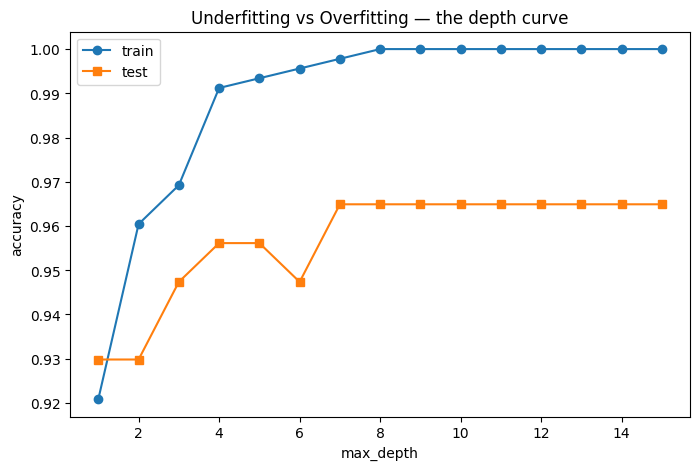

Highest test accuracy at max_depth = 7


In [12]:
# For each depth, fit a tree and store train AND test accuracy
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=1)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_acc, marker="o", label="train")
ax.plot(depths, test_acc, marker="s", label="test")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Underfitting vs Overfitting — the depth curve")
ax.legend()
plt.show()
best_depth = list(depths)[int(np.argmax(test_acc))]
print(f"Highest test accuracy at max_depth = {best_depth}")

**🔎 After running the cell**

Classic shape: **train accuracy marches to 1.0** (a deep enough tree memorises the training set) while **test accuracy peaks early and then sags** — that gap is overfitting / high variance. The sweet spot is shallow. This curve is precisely why we tune `max_depth` rather than leaving it unbounded.

<a id='part-7'></a>

## Part 7 — Hyperparameter Tuning with Weights & Biases

Eyeballing one curve only tunes one knob. Now we search several hyperparameters at once and log **every configuration to [Weights & Biases](https://wandb.ai)** so the whole sweep becomes an interactive, shareable dashboard.



**📝 Before you run this cell**

First, **log in to W&B**. You need a free account — grab your key from [wandb.ai/authorize](https://wandb.ai/authorize). In Colab/Jupyter this opens an input box; on a local machine the key is saved to `~/.netrc` so you only do this once.

In [13]:
import wandb

# Authenticate with Weights & Biases.
# Get your key from https://wandb.ai/authorize
# (Use wandb.login(anonymous="allow") if you don't want to create an account.)
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jonathanlyj0123 (jonathanlyj0123-new-york-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**🔎 After running the cell**

A successful login prints your username. If you just want to experiment without an account, run `wandb.login(anonymous='allow')` or set the env var `WANDB_MODE=offline` to log to disk only.

**📝 Before you run this cell**

We sweep a small, readable grid over the three knobs that matter most for a tree: `max_depth`, `criterion`, and `min_samples_leaf`. For each combination we score it with **5-fold cross-validation on the training set** (never the test set) and open one **W&B run** per configuration — they all land in the same project dashboard.

In [14]:
import itertools

param_grid = {
    "max_depth":        [2, 3, 5, 8, None],
    "criterion":        ["gini", "entropy"],
    "min_samples_leaf": [1, 5, 20],
}
keys = list(param_grid)
combos = list(itertools.product(*param_grid.values()))
print(f"{len(combos)} configurations to evaluate")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
WB_PROJECT = "ds4e-decision-tree"
results = []

for values in combos:
    params = dict(zip(keys, values))
    clf = DecisionTreeClassifier(**params, random_state=1)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy")

    run = wandb.init(
        project=WB_PROJECT, config=params,
        name=f"depth={params['max_depth']}_{params['criterion']}_leaf={params['min_samples_leaf']}",
        reinit=True)
    wandb.log({"cv_accuracy": scores.mean(), "cv_std": scores.std()})
    wandb.finish()

    results.append({**params, "cv_accuracy": scores.mean(), "cv_std": scores.std()})

results_df = pd.DataFrame(results).sort_values("cv_accuracy", ascending=False)
results_df.head(10)

30 configurations to evaluate


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


cv_accuracy,▁
cv_std,▁
cv_accuracy,0.92967
cv_std,0.03077


cv_accuracy,▁
cv_std,▁
cv_accuracy,0.92967
cv_std,0.03077


cv_accuracy,▁
cv_std,▁
cv_accuracy,0.93407
cv_std,0.03475


...

cv_accuracy,▁
cv_std,▁
cv_accuracy,0.93407
cv_std,0.03475


cv_accuracy,▁
cv_std,▁
cv_accuracy,0.92747
cv_std,0.02997


cv_accuracy,▁
cv_std,▁
cv_accuracy,0.94286
cv_std,0.02241


cv_accuracy,▁
cv_std,▁
cv_accuracy,0.92747
cv_std,0.04589


,max_depth,criterion,min_samples_leaf,cv_accuracy,cv_std
10,3.0,entropy,5,0.942857,0.021308
16,5.0,entropy,5,0.942857,0.022413
22,8.0,entropy,5,0.942857,0.022413
28,NaN,entropy,5,0.942857,0.022413
9,3.0,entropy,1,0.936264,0.026374
8,3.0,gini,20,0.934066,0.034750
19,8.0,gini,5,0.934066,0.037427
20,8.0,gini,20,0.934066,0.034750
26,NaN,gini,20,0.934066,0.034750
25,NaN,gini,5,0.934066,0.037427


**🔎 After running the cell**

Thirty runs now populate your **ds4e-decision-tree** project. Open the dashboard: the **parallel-coordinates** and **scatter** panels let you see at a glance which depth and leaf size win. We logged *cross-validated* accuracy — logging test accuracy for every config would be data leakage (Bonus 5).

**📝 Before you run this cell**

Pick the winning configuration straight from the results list (we keep the raw Python values so `None` for `max_depth` survives instead of turning into `NaN` in the table).

In [15]:
# Select the dict in `results` with the highest 'cv_accuracy'
best = max(results, key=lambda r: r["cv_accuracy"])
best_params = {k: best[k] for k in ("max_depth", "criterion", "min_samples_leaf")}
print(f"Best configuration : {best_params}")
print(f"Best CV accuracy   : {best['cv_accuracy']:.4f} ± {best['cv_std']:.4f}")

Best configuration : {'max_depth': 3, 'criterion': 'entropy', 'min_samples_leaf': 5}
Best CV accuracy   : 0.9429 ± 0.0213


**🔎 After running the cell**

The cross-validated winner is typically a **moderate depth with a larger `min_samples_leaf`** — the regularising effect of bigger leaves beats an unbounded tree, exactly as the depth curve predicted. These are the hyperparameters we now lock in for the final model.

<a id='part-8'></a>

## Part 8 — Final Held-out Evaluation

Tuning is done. We refit **one** model with the best hyperparameters on the full training set, then score it **once** on the held-out test set. After this point we do not touch the test set again — peeking and re-tuning would invalidate the number.



**📝 Before you run this cell**

Refit with `best_params`, predict on the test set, and print accuracy plus a full `classification_report` (precision / recall / F1 per class — important on imbalanced medical data, where missing a malignant case is the costly error).

In [16]:
# Refit on the full train set with best_params, predict, report
final_tree = DecisionTreeClassifier(**best_params, random_state=1)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)

acc = metrics.accuracy_score(y_test, y_pred)
print(f"Final test accuracy: {acc:.4f}\n")
print(metrics.classification_report(y_test, y_pred, target_names=class_names))

Final test accuracy: 0.9649

              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



**🔎 After running the cell**

Compare the test accuracy with the cross-validated score from Part 7 — they should be close. A big gap (CV high, test low) would mean we over-tuned to the CV folds, a real risk on small datasets. Watch the **recall for `malignant`**: that is the share of cancers we correctly flag.

**📝 Before you run this cell**

A confusion matrix shows *where* the errors fall — in particular how many malignant tumours were missed (false negatives, bottom-left).

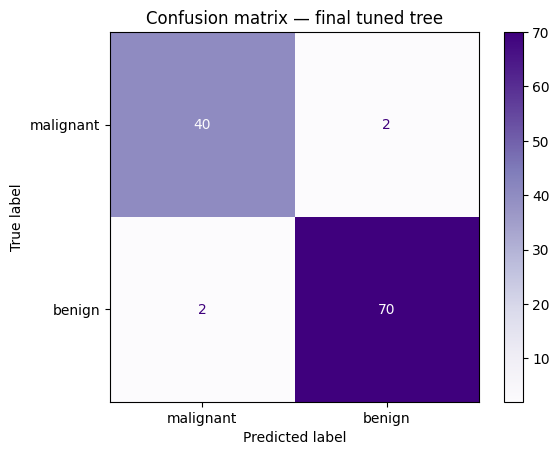

In [17]:
# Confusion matrix + ConfusionMatrixDisplay
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Purples")
plt.title("Confusion matrix — final tuned tree")
plt.show()

**🔎 After running the cell**

Off-diagonal cells are mistakes. In a clinical setting the **bottom-left** cell (malignant predicted benign) is the dangerous one; you would tune the decision threshold or class weights to shrink it even at the cost of a few extra false alarms.

**📝 Before you run this cell**

Finally, **explain the tuned model the same way we explained the first one** — render it with Graphviz. This closes the loop: a model that is both *tuned* and *transparent*.

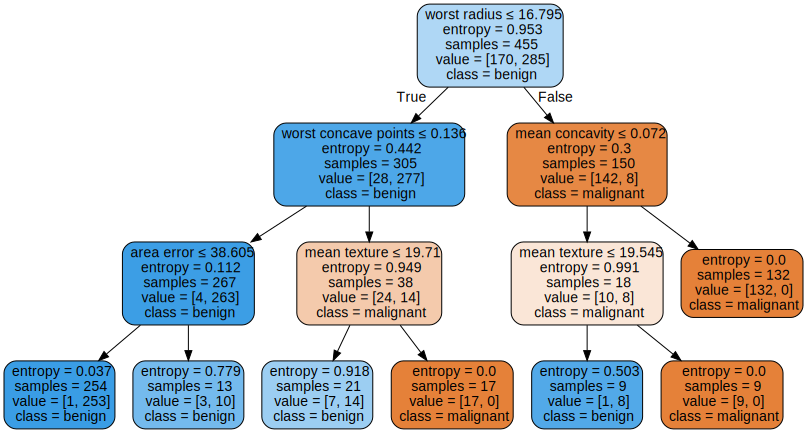

In [18]:
# Render the FINAL tuned tree with export_graphviz + graphviz.Source
dot_data = export_graphviz(
    final_tree, out_file=None,
    feature_names=X.columns, class_names=class_names,
    filled=True, rounded=True, special_characters=True)
graphviz.Source(dot_data)

**🔎 After running the cell**

The tuned tree is deeper than the depth-2 starter, so it captures more structure — but each path is still a readable chain of conditions. That combination of accuracy *and* explainability is exactly why decision trees (and their ensembles) remain a first-choice model for tabular data.

**📝 Before you run this cell**

Optional but satisfying: log the final model's test accuracy back to W&B as a dedicated run so your dashboard tells the full story — login, sweep, and the chosen model side by side.

In [19]:
# Log the final model's test accuracy back to W&B as a dedicated run
run = wandb.init(project=WB_PROJECT, config=best_params,
                 name="final-tuned-tree", reinit=True)
wandb.log({"test_accuracy": acc})
wandb.finish()

test_accuracy,▁
test_accuracy,0.96491


**🔎 After running the cell**

Your W&B project now contains the whole experiment trail: 30 sweep runs plus the final model. That reproducible, shareable record — not a screenshot of one number — is what separates a tidy ML workflow from an ad-hoc one.

<a id='bonus'></a>

---

## ✨ Bonus Questions

These questions are optional but **highly encouraged**. They go slightly beyond the core material and are great talking points for technical interviews.


**Bonus 1.** The slides note that decision trees **don't require feature scaling**. Explain why a tree is invariant to any *monotonic* rescaling of a single feature (e.g. multiplying `mean radius` by 1000), whereas KNN and logistic regression are not.

**Bonus 2.** Gini and entropy almost always pick the same tree. Show that both equal 0 for a pure node and are maximised for a 50/50 split, then give one practical reason scikit-learn defaults to Gini.

**Bonus 3.** Your depth curve showed train accuracy → 1.0 while test accuracy plateaued. Frame this with the **bias–variance** trade-off, and name the difference between **pre-pruning** (e.g. `max_depth`, `min_samples_leaf`) and **post-pruning** (`ccp_alpha` cost-complexity pruning).

**Bonus 4.** `feature_importances_` is biased toward high-cardinality / continuous features. Describe **permutation importance** and explain why shuffling a feature on held-out data gives a fairer, model-agnostic importance score.

**Bonus 5.** In the W&B sweep we logged **cross-validated** accuracy, not test accuracy. Why would logging the test score for every one of the 30 configurations be a form of data leakage, and what is the correct train / validation / test protocol?



###  Bonus Answers

**Bonus 1 — Why trees are invariant to monotonic rescaling.**
A decision tree only ever asks threshold questions of the form *"is feature ≤ t?"*. The split is chosen by the *ordering* (rank) of the values, not their magnitudes. Any strictly monotonic transform (×1000, log, etc.) preserves that ordering, so the tree just learns a rescaled threshold (e.g. `radius ≤ 15` becomes `radius ≤ 15000`) and produces the *identical* partition and predictions. KNN and logistic regression instead use *distances* / weighted sums across features, so a feature on a larger numeric scale dominates the Euclidean distance or the linear combination — they need standardization, trees do not.

**Bonus 2 — Gini and entropy at the extremes.**
For a pure node one class has p=1, the rest p=0. Gini = 1 − Σpᵢ² = 1 − 1² = **0**; Entropy = −Σpᵢlog₂pᵢ = −1·log₂1 = **0**. For a 50/50 binary split (p=0.5 each): Gini = 1 − (0.25+0.25) = **0.5** (its maximum for 2 classes); Entropy = −(0.5·−1 + 0.5·−1) = **1 bit** (its maximum). Both are 0 at purity and peak at the uniform mix, so they rank candidate splits almost identically. Practical reason scikit-learn defaults to **Gini**: it avoids the `log` computation, making it slightly cheaper while giving virtually the same trees.

**Bonus 3 — Bias–variance and pruning.**
Train→1.0 with test plateauing is the classic **high-variance / overfitting** regime: a deep tree has low bias (it can memorize the training set) but high variance (it captures noise that doesn't generalize). A shallow tree is the opposite — higher bias, lower variance. The sweet spot trades them off. **Pre-pruning** stops growth *during* training via hyperparameters (`max_depth`, `min_samples_leaf`, `min_samples_split`, `max_leaf_nodes`). **Post-pruning** grows a full tree, then prunes it back — scikit-learn's `ccp_alpha` does *cost-complexity pruning*, removing branches whose accuracy gain doesn't justify their added complexity (penalty α per leaf).

**Bonus 4 — Permutation importance.**
Impurity-based `feature_importances_` rewards features with many distinct split points, so continuous / high-cardinality features look more important than they are. **Permutation importance** is computed on held-out data: measure baseline accuracy, then randomly **shuffle one feature's column** (breaking its relationship with the target) and re-measure. The drop in score is that feature's importance. Because it watches the *actual* model's performance degrade on unseen data, it is model-agnostic and unbiased toward feature type — a feature the model truly relies on causes a big drop when scrambled; an unused one causes none.

**Bonus 5 — Why logging test accuracy per config is leakage.**
The test set must be touched **once**, after all model selection is final. If we scored all 30 configurations on the test set and picked the best, we'd be *selecting hyperparameters using the test set* — its information leaks into the chosen model, and the reported number is optimistically biased (we'd be fitting to the test set's noise). Correct protocol: **train** to fit parameters, **validation** (here, 5-fold CV inside the training set) to choose hyperparameters, and a **test** set held out untouched until the single final evaluation.


---

<div align="center" style="font-family:Helvetica,Arial,sans-serif;color:#555;font-size:13px;margin-top:30px">

✅ <b>Don’t forget to push your work to GitHub.</b><br><br>

<hr style="border:0;border-top:1px solid #57068C;width:50%">

<b>DS4EVERYONE — DS-UA 9111</b> · New York University<br>
Session 10 — Decision Trees<br>
© Professor Gaëtan Brison © — All rights reserved.

</div>
